In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'sysstrat' folder
project_root = Path.cwd()
while not (project_root / "sysstrat").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'sysstrat' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies


In [2]:
import pandas as pd
from sysstrat import (
    load_simple_price_csv,
    VectorizedEngine,
    FixedRiskPositionStrategy,
    PortfolioAnalyzer,
    plot_results,
    plot_backtest_results
)

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-08-07 13:27:10.939 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-08-07 13:27:10.949 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


In [4]:
INITIAL_CAPITAL = 100000
VOLATILITY_WINDOW = 63
RISK_TARGET = 0.1
MULTIPLIER=1.0
MAX_LEVERAGE=1
COMMISSION_RATE=0.0005
SLIPPAGE_RATE=0.0005

In [5]:
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,     
    commission_rate=COMMISSION_RATE,
    slippage_rate=SLIPPAGE_RATE
)

In [6]:
strategy = FixedRiskPositionStrategy(volatility_window=VOLATILITY_WINDOW, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)
strategy2 = FixedRiskPositionStrategy(vol_method="blended", short_span=31, long_span=2520, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)

In [7]:
result = engine.run(strategy, data)
result2 = engine.run(strategy2, data)

In [8]:
result.print_summary()
result2.print_summary()

┌──────────────────────────────────────────────────────────────────────┐
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +8.2% │
│ Average drawdown                         │                    -2.3% │
│ Maximum drawdown                         │                   -28.0% │
│ Annualised standard deviation            │                    10.9% │
│ Sharpe ratio                             │                     0.75 │
│ Skew                                     │                    -1.00 │
│ Lower tail                               │                     1.66 │
│ Upper tail                               │                     1.25 │
└──────────────────────────────────────────────────────────────────────┘
┌──────────────────────────────────────────────────

c:\Users\igorp\OneDrive\Документы\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


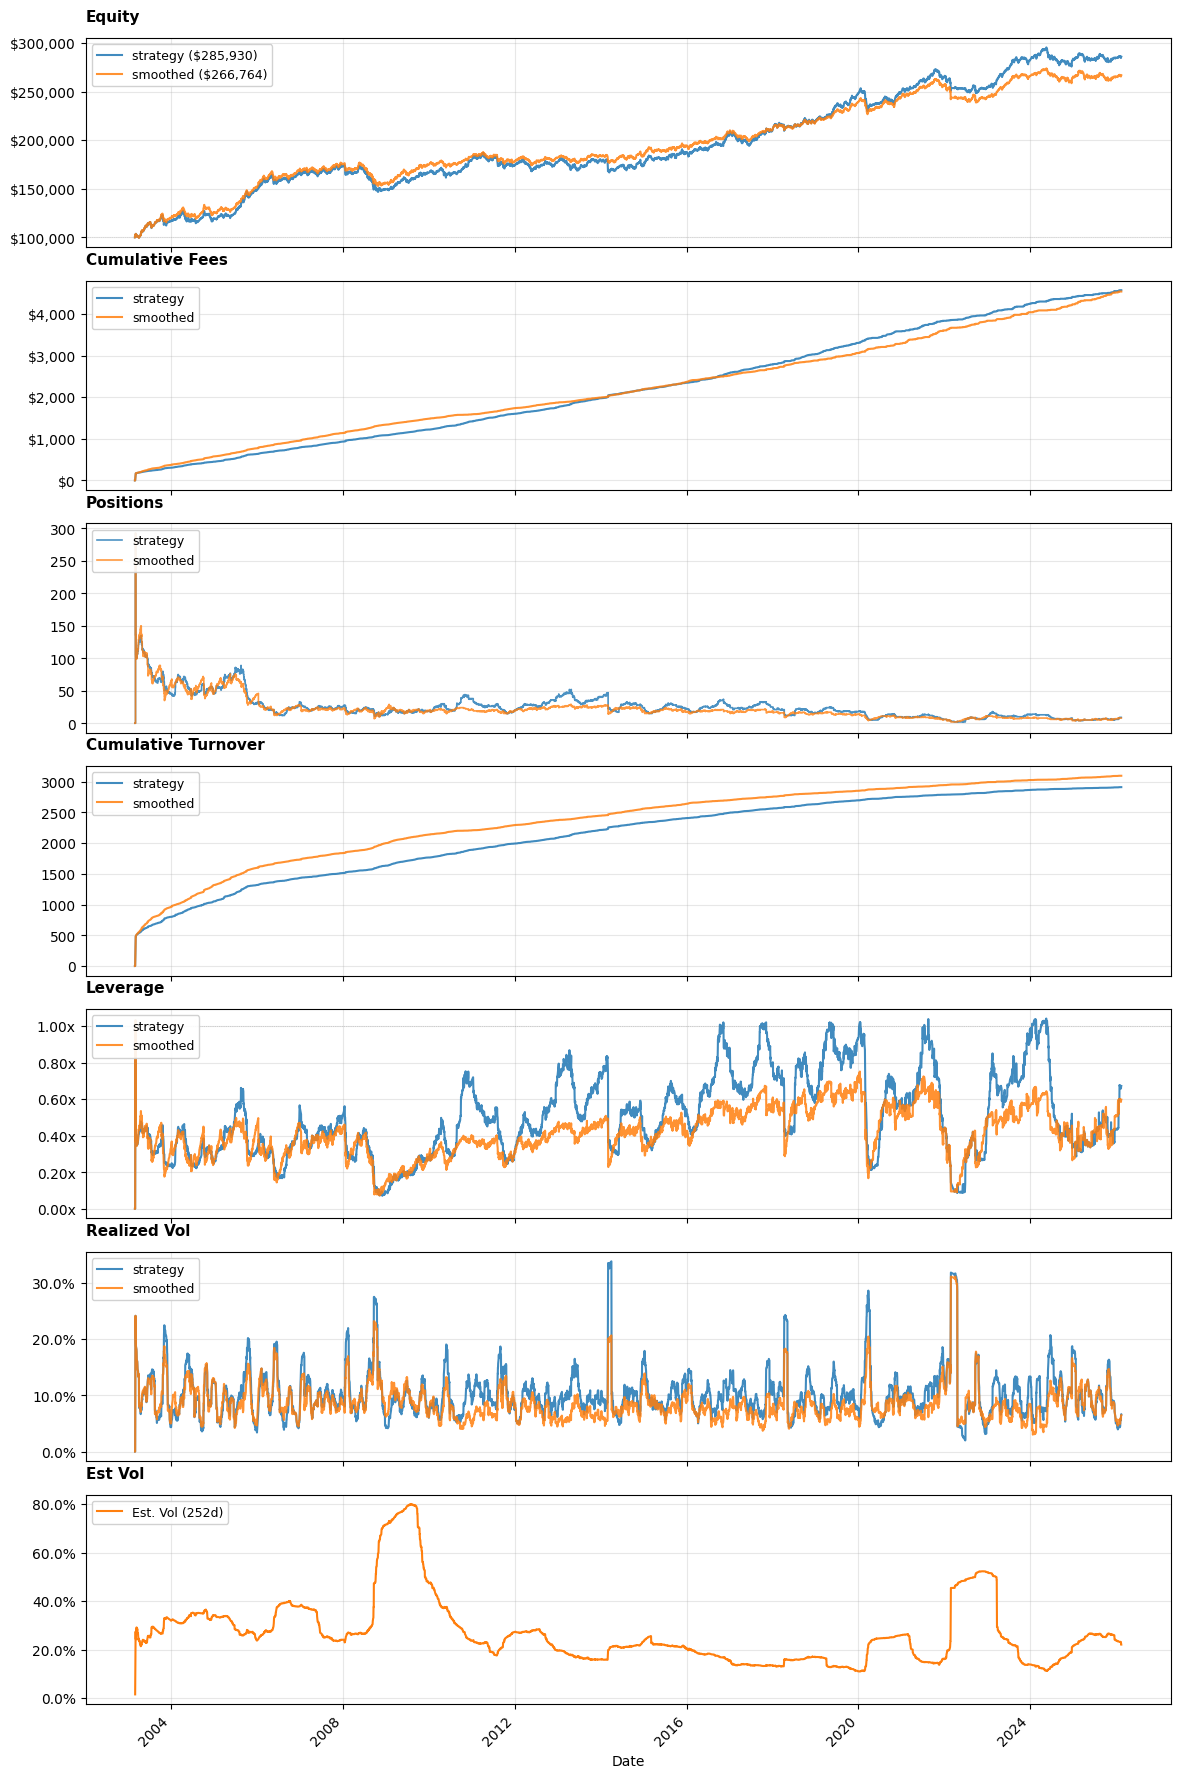

In [9]:
plot_backtest_results(
    results={"strategy": result, "smoothed": result2},
    panels=['equity', 'cumulative_fees', 'positions','cumulative_turnover', 'leverage', "realized_vol", "est_vol"],
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)

In [10]:
portfolio_weights = [1]
risk_free_rate = 0.0 

# Initialize the analyzer
analyzer = PortfolioAnalyzer(
    strategies=[result2],
    names=["1"],
    weights=portfolio_weights,
    risk_free_rate=risk_free_rate,
    trading_days_per_year=252
)

print("✅ PortfolioAnalyzer initialized successfully.")

✅ PortfolioAnalyzer initialized successfully.


In [11]:
portfolio_result = analyzer.run()

In [12]:
portfolio_result.print_summary()


════════════════════════════════════════════════════════════════════════════════
 PORTFOLIO ANALYSIS SUMMARY
════════════════════════════════════════════════════════════════════════════════

Strategy Allocation:
  1                             :  100.0%

────────────────────────────────────────────────────────────────────────────────
Portfolio Performance Metrics:
────────────────────────────────────────────────────────────────────────────────
  Total Return                                    +166.76%
  CAGR                                              +7.32%
  Annual Volatility                                  9.18%
  Sharpe Ratio                                        0.80
  Sortino Ratio                                     104.03
  Max Drawdown                                     -24.19%
  Gross Sharpe                                        0.86
  Fee Drag Ratio                                      0.03

──────────────────────────────────────────────────────────────────────────────

In [13]:
portfolio_as_backtest = portfolio_result.to_backtest_result(name="Diversified Portfolio")

AttributeError: 'PortfolioResult' object has no attribute 'results'

ValueError: 'price_data' is required in BacktestResult for price or est_vol panels.

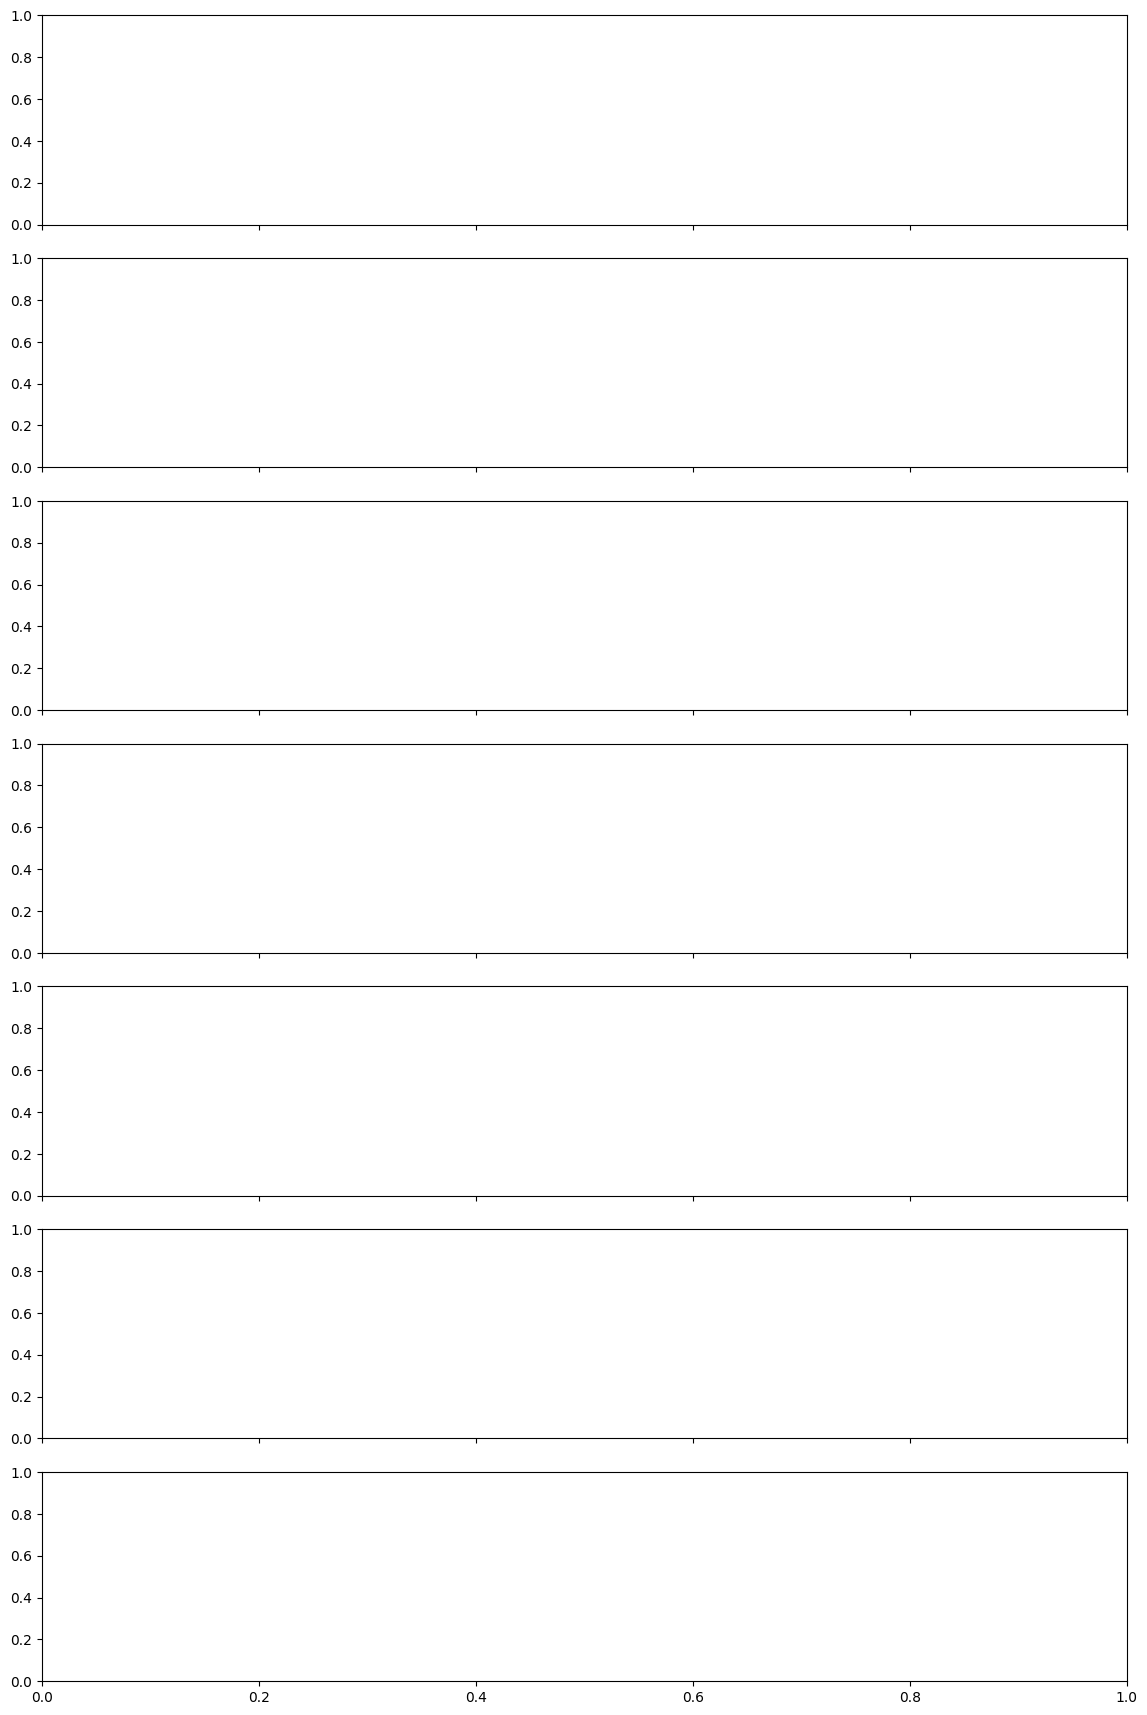

In [ ]:
plot_backtest_results(
    results={"strategy": portfolio_as_backtest},
    panels=['equity', 'cumulative_fees', 'positions','cumulative_turnover', 'leverage', "realized_vol", "est_vol"],
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)

In [ ]:
# Add this after portfolio = analyzer.run()
print("\n--- PORTFOLIO LEVERAGE DEBUG ---")
for result in analyzer.results:
    name = result.strategy_name or result.ticker
    
    # 1. Check raw inputs
    avg_pos = result.positions.mean()
    avg_price = result.price_data.mean() if result.price_data is not None else 0
    pv = result.point_value
    
    # 2. Calculate individual notional
    if result.price_data is not None:
        notional = (result.positions * result.price_data * pv)
        avg_notional = notional.mean()
    else:
        avg_notional = 0
        
    # 3. Check alignment (NaNs will destroy the sum)
    pos_count = result.positions.count()
    price_count = result.price_data.count() if result.price_data is not None else 0
    
    print(f"[{name}]")
    print(f"  Avg Position (Contracts): {avg_pos:.4f}")
    print(f"  Avg Price:                {avg_price:.2f}")
    print(f"  Point Value:              {pv}")
    print(f"  Avg Notional Exposure:    {avg_notional:,.0f}")
    print(f"  Data Alignment (Pos/Price): {pos_count} / {price_count}")
    print("-" * 40)

print(f"Total Portfolio Equity (Avg): {analyzer.portfolio_equity.mean():,.0f}")
print(f"Calculated Portfolio Leverage (Avg): {analyzer.portfolio_leverage.mean():.4f}")


--- PORTFOLIO LEVERAGE DEBUG ---
[FixedRiskPositionStrategy]
  Avg Position (Contracts): 21.9974
  Avg Price:                3038.77
  Point Value:              1.0
  Avg Notional Exposure:    41,534
  Data Alignment (Pos/Price): 5739 / 5739
----------------------------------------
Total Portfolio Equity (Avg): 196,982
Calculated Portfolio Leverage (Avg): 0.2143
